# Notebook to develop the gradient of an ensemble covariance

For a given ensemble of realization $\mathbf{X}^{l}$ at iteration $l$ of shape $(N_{s}, N_{e})$, we ca write the anomaly matrix as:

$$ \mathbf{A}^{l} = \mathbf{X}^{l}\left(\mathbf{I_{N_{e}}} - \dfrac{1}{N_{e}} \mathbf{11}^{T} \right) / \sqrt{N_{e}-1}$$

and with the misfit objective function with respect to the $j^{\mathrm{th}}$ member of the ensemble:

$$
\mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) = \dfrac{1}{2} \left(\mathbf{d}_{\mathrm{obs}} - h(\mathbf{X}_{j}^{l})\right)^{T} \mathbf{C}_{dd}^{-1} \left(\mathbf{d}_{\mathrm{obs}} - h(\mathbf{X}_{j}^{l})\right)
$$

The new normalized objective function can be written as the sum of member objective functions. TODO:: eventuellement perturber les observations pour ajouter du stochastique.

$$
\begin{split}
\mathcal{J}_{j}(\mathbf{X}^{l}) = & \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) + \dfrac{\alpha_{\mathrm{reg}}}{2} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)^{T} \mathbf{C}_{xx}^{-1} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)
\\
= & \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) +  \dfrac{\alpha_{\mathrm{reg}}}{2} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)^{T} \left(\mathbf{A}\mathbf{A}^{T}\right)^{-1} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)
\end{split}
$$

$$
\begin{split}
\mathcal{J}(\mathbf{X}^{l}) &= \dfrac{1}{N_{e}} \sum_{j=1}^{N_{e}} \mathcal{J}_{j}(\mathbf{X}^{l})
\\
& = \dfrac{1}{N_{e}} \sum_{j=1}^{N_{e}} \left( \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) + \dfrac{\alpha_{\mathrm{reg}}}{2} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)^{T} \left(\mathbf{A}\mathbf{A}^{T}\right)^{-1} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right) \right)
\end{split}
$$

Optimizing this function, all ensemble members are linked through the regularization term. With gradient optimization, the ensemble can be optimized at once, in such case, the heavy part is computing the forward operator $h$, the regularization term is still cheap to compute. We must compute the derivative w.r.t. to each column of $\mathbf{X}^{l}$ and stack them vertically:

$$
\begin{split}
\nabla \mathcal{J}(\mathbf{X}^{l}) |_{\mathbf{X}_{k}^{l}}&= \dfrac{1}{N_{e}} \sum_{j=1}^{N_{e}} \nabla \mathcal{J}_{j}(\mathbf{X}^{l}) |_{\mathbf{X}_{k}^{l}}
\\
& = \dfrac{1}{N_{e}} \nabla \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) |_{\mathbf{X}_{k}^{l}} + \dfrac{1}{N_{e}} \nabla \left(\sum_{j=1}^{N_{e}} \mathcal{J}_{\mathrm{obs}} (\mathbf{X}^{l}) + \dfrac{\alpha_{\mathrm{reg}}}{2} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right)^{T} \left(\mathbf{A}\mathbf{A}^{T}\right)^{-1} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right) \right) \Bigg|_{\mathbf{X}_{k}^{l}}
\end{split}
$$


The derivative of the observation misfit term is given by the adjoint state: $ \nabla \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{j}^{l}) |_{\mathbf{X}_{k}^{l}}$. It it non null only if $k = j$ It can be computed in parallel in an ensemble smoother or PCGA fashion.

Note that here, we use the product rule and the fact that for a non singular matrix $\mathbf{K}$, the derivative of its inverse $\nabla (\mathbf{K}^{-1})'$ reads $- \mathbf{K}^{-1}\nabla\left(\mathbf{K}\right)\mathbf{K}^{-1}$ \ref = golubMatrixComputations1996, dhrymesMathematicsEconometrics2013

And the product rule:
$$ y = f(x) g(x) h(x) $$

Then

$$ \dfrac{\partial y}{\partial x} = f'(x) g(x) h(x) + f(x) g'(x) h(x) + f(x)g(x) h'(x) $$
 
The derivative of the second term is explicit:


$$ \nabla \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right) \Big|_{\mathbf{X}_{k}^{l}} = \begin{cases} \mathbf{I} - \dfrac{1}{N_{e}} \mathbf{11}^{T}  &, \text{if} \; k = j \\ - \dfrac{1}{N_{e}} \mathbf{11}^{T} &, \text{if} \; k \neq j\end{cases}

$$ \nabla \left(\mathbf{A}^{}\mathbf{A}^{T}\right) \Big|_{\mathbf{X}_{k}^{l}} = \dfrac{1}{N_{e} - 1} \left( \mathbf{X}^{l}\left(\mathbf{I_{N_{e}}} - \dfrac{1}{N_{e}} \mathbf{11}^{T} \right) \mathbf{A}^{T} + \mathbf{A} \left( \mathbf{X}^{l}\left(\mathbf{I_{N_{e}}} - \dfrac{1}{N_{e}} \mathbf{11}^{T} \right)\right)^{T}\right)

# Ce que j'ai codé avec une matrix fixe:

$$
\begin{split}
\nabla \mathcal{J}(\mathbf{X}^{l}) |_{\mathbf{X}_{k}^{l}}&= \dfrac{1}{N_{e}} \sum_{j=1}^{N_{e}} \nabla \mathcal{J}_{j}(\mathbf{X}^{l}) |_{\mathbf{X}_{k}^{l}}
\\
& = \dfrac{1}{N_{e}} \nabla \mathcal{J}_{\mathrm{obs}} (\mathbf{X}_{k}^{l}) |_{\mathbf{X}_{k}^{l}} + \dfrac{\alpha_{\mathrm{reg}}}{N_{e}} \left( \left(\mathbf{A}\mathbf{A}^{T}\right)^{-1} \left(\mathbf{X}_{k}^{l} - \overline{\mathbf{X}^{l}}\right) + \dfrac{1}{N_{e}} \sum_{j=1}^{N_{e}} \left(\mathbf{A}\mathbf{A}^{T}\right)^{-1} \left(\mathbf{X}_{j}^{l} - \overline{\mathbf{X}^{l}}\right) \right)
\end{split}
$$



# This is only good if one uses the sparse covariance matrix initially produced. The prior term changes and depends on the ensemble rather than on the vector itself.

Note that the dense matrix never has to be computed.

In [1]:
from typing import Union
import numpy as np
import pyrtid.utils.spde as spde
from scipy.sparse.linalg import gmres
from sksparse.cholmod import cholesky
from pyrtid.utils import NDArrayFloat
from pyrtid.inverse.regularization import GeostatisticalRegularizator
from pyrtid.inverse.regularization.covariances import (
    CovarianceMatrix,
    CallBack,
    SparseInvCovarianceMatrix,
)
from pyrtid.inverse.regularization.priors import PriorTerm

import matplotlib.pyplot as plt

In [2]:
nx = 10  # number of voxels along the x axis + 4 * 2 for the borders (regularization)
ny = 10  # number of voxels along the y axis
nz = 1
dx = 5.0  # voxel dimension along the x axis
dy = 5.0  # voxel dimension along the y axis
dz = 1.0

len_scale = 20.0  # m
kappa = 1 / len_scale
alpha = 1.0

mean = 300.0  # trend of the field
std = 150.0  # standard deviation of the field

# Create a precison matrix
Q_ref = spde.get_precision_matrix(
    nx, ny, nz, dx, dy, dz, kappa, alpha, spatial_dim=2, sigma=std
)
cholQ_ref = cholesky(Q_ref)
# Non conditonal simulation -> change the random state to obtain a different field
simu_ = spde.simu_nc(cholQ_ref, random_state=2026).reshape(ny, nx).T
reference_grade = np.abs(simu_ + mean)

In [3]:
tmp = []
n_fields = 50
for i in range(n_fields):
    _field = np.abs(
        spde.simu_nc(cholQ_ref, random_state=i).reshape(ny, nx).T.reshape(ny, nx).T
        + mean
    )

    tmp.append(np.where(_field < 0.0, 0.0, _field).ravel("F"))
initial_ensemble_values_ppm = np.array(tmp).T
initial_ensemble_values_ppm.shape

(100, 50)

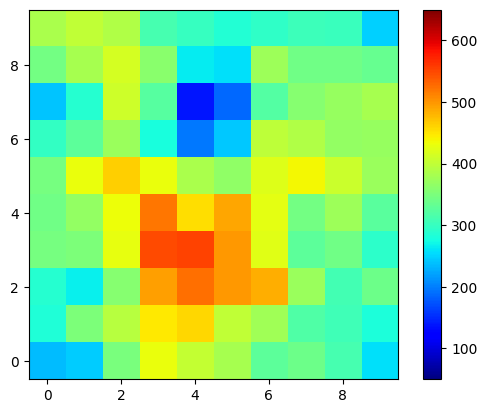

In [4]:
plt.imshow(
    initial_ensemble_values_ppm[:, 3].reshape(nx, ny),
    origin="lower",
    cmap=plt.get_cmap("jet"),
    aspect="equal",
    vmin=50.0,
    vmax=650,
)
plt.colorbar()

In [5]:
class EnsembleCovarianceMatrix(CovarianceMatrix):
    r"""
    Represents a covariance matrix as an ensemble of realizations.

    For a given ensemble with shape (:math:`N_{s}`, :math:`N_{e}`), the number of
    points and the number of members in the ensemble respectively, the covariance
    matrix :math:`\mathbf{\Sigma_{ss}}` is approximated from the ensemble
    in the standard way of EnKF
    :cite:p:`evensenDataAssimilationEnsemble2007,aanonsenEnsembleKalmanFilter2009`:

    .. math::
        \mathbf{\Sigma_{ss}} = \frac{1}{N_{e} - 1} \sum_{j=1}^{N_{e}}\left(s_{j} -
        \overline{s}\right)\left(s_{j}
        - \overline{s^{l}} \right)^{T}

    Or by defining a matrix of anomalies
    :math:`\mathbf{A} = \mathbf{S} - \overline{\mathbf{S}}`
    with shape  (:math:`N_{s}`, :math:`N_{e}`):

    .. math::
        \mathbf{\Sigma_{ss}} = \frac{1}{N_{e} - 1} \mathbf{A}^{T}\mathbf{A}

    Note
    ----
    Practically, the dense covariance matrix is never built,
    only the anomalies matrix :math:`\mathbf{A}` is used. The product between the
    inverse of the covariance matrix and a vector
    :math:`\mathbf{x} = \mathbf{\Sigma_{ss}}^{-1}\mathbf{b}`
    is obtained solving the system :math:`\mathbf{A}^{T}\mathbf{Ax} = \mathbf{b}`,
    using gmres, where only anomalies matrix vector products are required.
    """

    def __init__(
        self,
        ensemble: NDArrayFloat,
    ) -> None:
        """
        Initiate the instance.

        Parameters
        ----------
        ensemble : NDArrayFloat
            Ensemble of realization with shape (:math:`N_{s}`, :math:`N_{e}`).
        """
        # on axis 1, the number of parameters
        super().__init__((ensemble.shape[0], ensemble.shape[0]))
        self.ensemble = ensemble

    @property
    def anomalies(self) -> NDArrayFloat:
        """
        Return the matrix of anomalies.

        """
        return self.ensemble - np.mean(self.ensemble, axis=1, keepdims=True) / np.sqrt(self.ensemble.shape[1])

    @property
    def n_ens(self) -> int:
        """Return the number of members in the ensemble."""
        return self.ensemble.shape[0]

    # def matvec(self, x: NDArrayFloat) -> NDArrayFloat:
    #     """Return the covariance matrix times the vector x (dot product)."""
    #     return np.linalg.multi_dot([self.anomalies.T, self.anomalies, x]) / (
    #         self.n_ens - 1
    #     )  # type: ignore

    def _matvec(self, x: NDArrayFloat) -> NDArrayFloat:
        """Return the covariance matrix times the vector x (dot product)."""
        return np.linalg.multi_dot([self.anomalies, self.anomalies.T, x]) / (
            self.n_ens - 1
        )  # type: ignore
    
    def todense(self) -> NDArrayFloat:
        """
        Return a dense representation of the matrix.
        """
        return self.anomalies @ self.anomalies.T / (self.n_ens - 1)

    def solve(self, x: NDArrayFloat) -> NDArrayFloat:
        """Return $Q^{-1} x$."""
        return self.solve(x)

    def solve(
        self, b: NDArrayFloat, tol: float = 1e-12, maxiter: int = 1000
    ) -> NDArrayFloat:
        """
        Solve A^{T}Ax = b, with A, the anomalies matrix instance.

        Note that the dense covariance matrix is never built.
        """
        residual = CallBack()
        x, info = gmres(
            self,
            b,
            tol=tol,
            maxiter=maxiter,
            callback=residual,
            atol=0.0,
            callback_type="legacy",
        )
        self.solvmatvecs += residual.itercount
        return x

    def get_diagonal(self) -> NDArrayFloat:
        """Return the diagonal entries of the matrix (variances)."""
        return np.sum((self.anomalies**2), axis=0) / (self.n_ens - 1.0)

    def get_trace(self) -> float:
        """Return the trace of the covariance matrix."""
        return float(np.sum(self.get_diagonal()))


from typing import Tuple


    
from typing import Callable

import numpy as np

from pyrtid.inverse.regularization.base import Regularizator
from pyrtid.inverse.regularization.covariances import CovarianceMatrix
from pyrtid.inverse.regularization.priors import NullPriorTerm, PriorTerm
from pyrtid.utils.types import NDArrayFloat
from pyrtid.utils import finite_gradient


def identify_function(x: NDArrayFloat) -> NDArrayFloat:
    """Return x untransformed (f(x) = x)."""
    return x


def one(x: NDArrayFloat) -> NDArrayFloat:
    """Return 1.0, whatever the input."""
    return np.ones(x.shape)


class EnsembleRegul


SyntaxError: expected ':' (1708916174.py, line 139)

In [ ]:
mat = EnsembleCovarianceMatrix(initial_ensemble_values_ppm)
X = initial_ensemble_values_ppm

In [ ]:
xCx = X[:, 0].T.dot(mat.solve(X[:, 0]))
xCx

46.59946290766726

In [ ]:
np.dot(X[:, 0].T, Q_ref.dot(X[:, 0]))

416.02521900934585

# With the Q ref as matrix

In [ ]:
def getxQrefx(ens: NDArrayFloat, j: int) -> float:
    _res = ens[:, j] - np.mean(ens, axis=1)
    return 0.5 * _res.T @ Q_ref.dot(_res)


getxQrefx(X, 0)

43.0149708521416

In [ ]:
cov_mat = SparseInvCovarianceMatrix(Q_ref)
reg = EnsembleRegularizator(cov_mat, EnsembleMeanPriorTerm(X.shape))

In [ ]:
reg.loss_function(X)

49.439034939681015

In [ ]:
grad = reg.loss_function_gradient_analytical(X)
grad.shape

(100, 200)

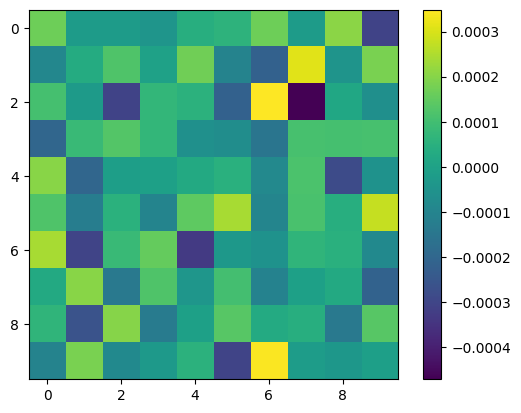

In [ ]:
plt.imshow(grad[:, 0].reshape((nx, ny)))
plt.colorbar()

In [ ]:
grad_fd = reg.loss_function_gradient(X, is_finite_differences=True)
grad_fd.shape

(100, 200)

In [ ]:
grad / grad_fd

array([[1.00000047, 1.0000011 , 1.00000325, ..., 0.9999901 , 0.99997838,
        0.99999905],
       [1.00001622, 0.99999822, 1.00000658, ..., 0.99999914, 0.99999508,
        0.99999548],
       [1.00000861, 1.00000156, 1.00000015, ..., 0.99999961, 0.99999609,
        1.00000272],
       ...,
       [1.00001407, 0.99999379, 0.99999846, ..., 1.00000163, 1.00000104,
        1.00000182],
       [1.000014  , 1.00000182, 0.99994607, ..., 0.99999954, 0.99999718,
        0.99999959],
       [0.99997492, 0.99994169, 0.9999992 , ..., 1.00000074, 0.99997195,
        0.99999868]])

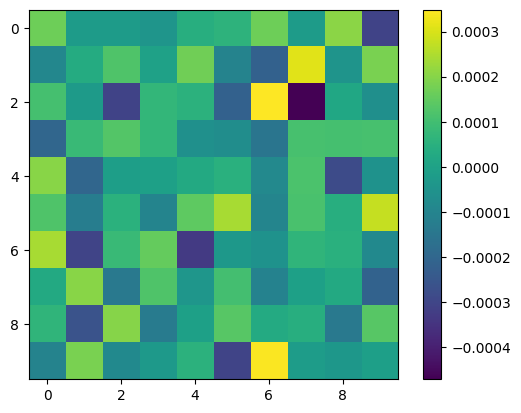

In [ ]:
plt.imshow(grad_fd[:, 0].reshape(nx, ny))
plt.colorbar()

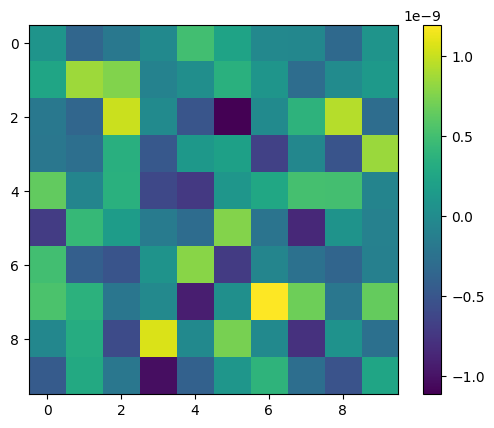

In [ ]:
plt.imshow((grad[:, 0] - grad_fd[:, 0]).reshape(nx, ny))
plt.colorbar()

In [ ]:
b = reg.loss_function_gradient(X, j=0, is_finite_differences=True, max_workers=1)

TypeError: Regularizator.loss_function_gradient() got an unexpected keyword argument 'j'

In [ ]:
b

array([-3.27183014e-05, -2.93660387e-02,  9.72309393e-03,  3.74769729e-03,
        6.70873260e-03, -2.19710185e-02, -3.14219697e-02,  2.86948732e-02,
       -5.03885772e-02, -1.44909314e-02, -5.55665120e-02,  5.41179667e-02,
       -2.00460686e-03, -4.83585389e-02,  8.34640072e-03, -8.23573921e-03,
        2.98676929e-02,  4.12726173e-02,  3.64004359e-02,  2.80275189e-02,
        8.04056524e-02, -5.04460377e-02,  4.18141030e-03, -1.29857352e-02,
        2.93819904e-02, -2.35178883e-02,  7.07089505e-03, -6.50188743e-02,
        1.12419290e-02, -2.11043352e-02, -4.19670008e-02,  1.33420372e-02,
       -2.24992583e-02,  7.69082874e-02, -5.12351163e-02,  1.71355302e-02,
        4.08509604e-02, -3.79263120e-03, -1.07430775e-02,  7.48731342e-03,
        9.67225317e-03,  4.25805574e-03, -4.42359032e-02,  2.33085808e-02,
        6.54977189e-03, -3.05456670e-02, -3.59319013e-02,  8.24245260e-02,
       -4.25358300e-02, -3.75958124e-02, -1.87600170e-02,  2.04109539e-02,
        1.18044882e-02,  

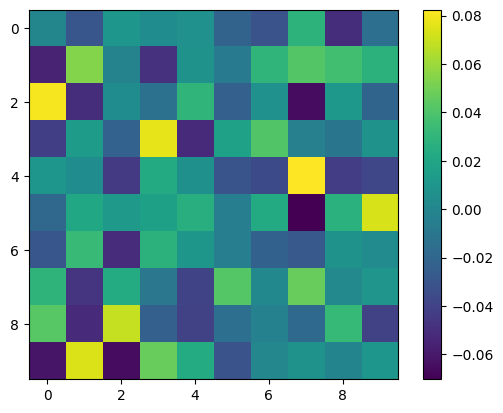

In [ ]:
plt.imshow(a.reshape(nx, ny))
plt.colorbar()

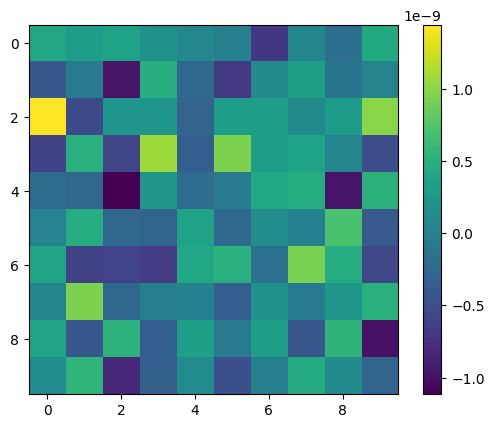

In [ ]:
plt.imshow((a - b).reshape(nx, ny))
plt.colorbar()

# Using the anomaly matrix

In [ ]:
def getxAAx(ens: NDArrayFloat, j: int) -> float:
    _res = ens[:, j] - np.mean(ens, axis=1)
    mat = EnsembleCovarianceMatrix(ens)
    return 0.5 * _res.T @ mat.solve(_res)


getxAAx(X, 0)

23.640582872293923

# Compute the derivatives

In [ ]:
def getxQrefxderiv(x: NDArrayFloat, j; int) -> NDArrayFloat:
    ens = initial_ensemble_values_ppm.copy()
    ens[:, j] = x
    residuals = ens[:, j] - np.mean(ens, axis=1)

    _right_part = Q_ref.dot(residuals).ravel()
    # left part gradient -> special method to get more efficient
    # $ [I - dm_{prior}/dm]^{T} Q^{-1} (m - m_{prior})$
    return (
        (_right_part - self.prior.get_gradient_dot_product(_right_part))
    )

    return _res.T @ Q_ref.dot(_res)

SyntaxError: invalid syntax (2443125069.py, line 1)